# Sales Data Analysis
Analysis of sales data to identify revenue trends by category, region and products.

In [28]:
import pandas as pd 
pd.options.display.float_format = '{:,.2f}'.format

df =pd.read_csv("sales_data.csv")
df.head()

,order_id,date,product,category,region,price,units_sold
0,1000,2025-01-21,Webcam,Accessories,North,56.20,8.00
1,1001,2025-04-27,Webcam,Accessories,West,55.20,11.00
2,1002,2025-06-07,Monitor,Electronics,West,206.04,2.00
3,1003,2025-02-27,keyboard,Accessories,West,NaN,33.00
4,1004,2025-06-19,keyboard,Accessories,East,40.71,27.00


## Data cleaning
removing for duplicates, handling missing value and standardizing the product names.

In [29]:
df_clean = df.drop_duplicates()


df_clean["price"] = df_clean["price"].fillna(df_clean["price"].mean())
df_clean["units_sold"] = df_clean["units_sold"].fillna(df_clean["units_sold"].mean())
df_clean["region"] = df_clean["region"].fillna("Unknown")
df_clean["product"] = df_clean["product"].str.capitalize()
df_clean = df_clean[df_clean["units_sold"] <= 100]

df_clean.shape

(297, 7)

## Analysis

In [30]:
df_clean["revenue"] = df_clean["price"] * df_clean["units_sold"]

revenue_by_category = df_clean.groupby("category")["revenue"].sum()
revenue_by_region = df_clean.groupby("region")["revenue"].sum()
avg_price_by_region = df_clean.groupby("region")["price"].mean()
top_product = df_clean.groupby("product")["revenue"].sum().idxmax()

print("Revenue by Category:")
print(revenue_by_category)
print("\nRevenue by Region:")
print(revenue_by_region)
print("\nAverage Price by Region:")
print(avg_price_by_region)
print("\nTop Revenue-Generating Product:", top_product)

Revenue by Category:
category
Accessories     276,282.58
Electronics   1,228,759.06
Name: revenue, dtype: float64

Revenue by Region:
region
East      227,746.41
North     485,865.75
South     320,548.23
Unknown    80,575.39
West      390,305.85
Name: revenue, dtype: float64

Average Price by Region:
region
East      183.35
North     282.80
South     272.46
Unknown   295.88
West      270.92
Name: price, dtype: float64

Top Revenue-Generating Product: Laptop


## visualization

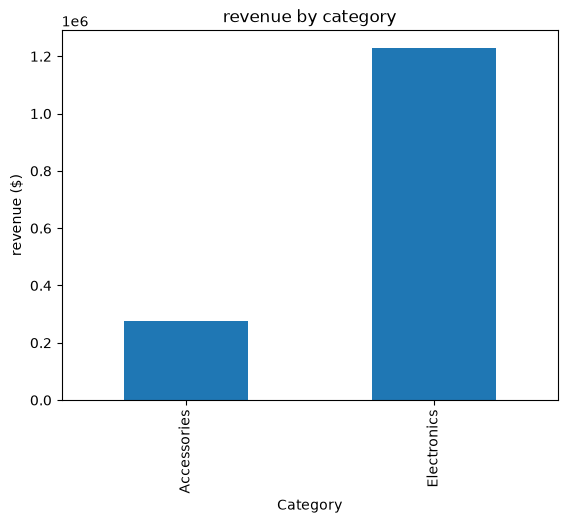

In [31]:
import matplotlib.pyplot as plt

revenue_by_category.plot(kind = "bar", title= "revenue by category")
plt.ylabel("revenue ($)")
plt.xlabel("Category")
plt.show()

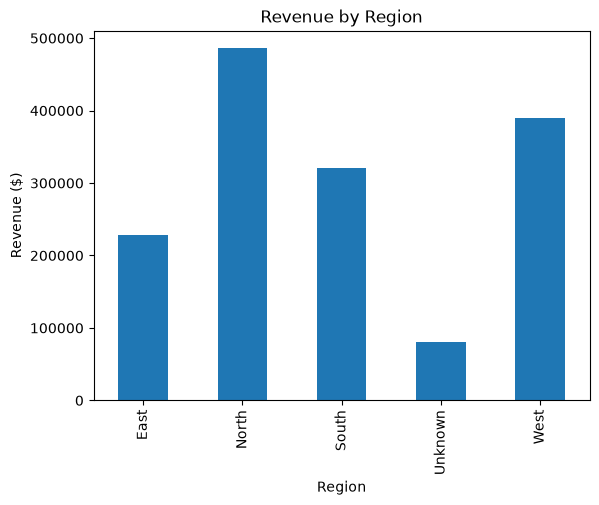

In [32]:
import matplotlib.pyplot as plt

revenue_by_region.plot(kind="bar", title="Revenue by Region")
plt.ylabel("Revenue ($)")
plt.xlabel("Region")
plt.show()

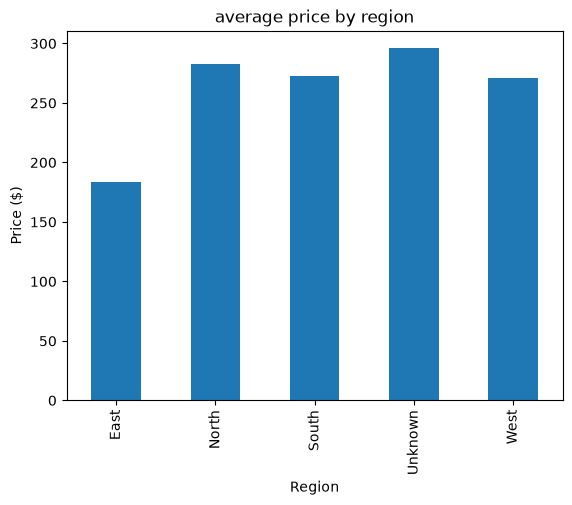

In [33]:
import matplotlib.pyplot as plt 

avg_price_by_region.plot(kind=("bar"), title=("average price by region"))
plt.ylabel("Price ($)")
plt.xlabel("Region")
plt.show()